<a href="https://colab.research.google.com/github/aisyashlf/Home-Credit-/blob/main/%5BML_%26_EDA%5D_Home_Credit_Scorecard_Model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('/content/drive/MyDrive/Home Credit/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Home Credit/test.csv')
df_sample = pd.read_csv('/content/drive/MyDrive/Home Credit/clean_sample.csv')
for_eda = pd.read_csv('/content/drive/MyDrive/Home Credit/for_eda.csv')

#IMBALANCE DATA

In [11]:
y = train['TARGET']

print("Jumlah tiap kelas:")
print(y.value_counts())

print("\nProporsi tiap kelas:")
print(y.value_counts(normalize=True))

Jumlah tiap kelas:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Proporsi tiap kelas:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


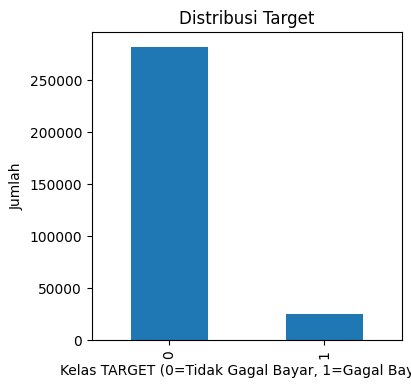

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
y.value_counts().plot(kind='bar')
plt.title("Distribusi Target")
plt.xlabel("Kelas TARGET (0=Tidak Gagal Bayar, 1=Gagal Bayar)")
plt.ylabel("Jumlah")
plt.show()

#MACHINE LEARNING

##LIGHTGBM

In [8]:
!pip install optuna

In [9]:
!pip install lightgbm --install-option=--gpu


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --install-option


In [10]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# === 1. Siapkan data ===
TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

X = train.drop([TARGET_COL, ID_COL], axis=1)
y = train[TARGET_COL]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 2. Objective Optuna ===

def objective(trial):

    params = {
        'device': 'gpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", -1, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
        "n_estimators": 3000,
        "class_weight": "balanced",
        "verbosity": -1    # <<< penting supaya tidak error
    }

    model = lgb.LGBMClassifier(**params)

    # pakai callbacks, bukan verbose
    callbacks = [
        lgb.early_stopping(200),
        lgb.log_evaluation(0)     # tidak mencetak log apa-apa
    ]

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=callbacks
    )

    preds = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, preds)

    return auc

# === 3. Jalankan tuning ===
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-12-06 14:14:17,247] A new study created in memory with name: no-name-406e38ab-d7f6-4372-8098-ab2e767f5fc8


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1377]	valid_0's auc: 0.781279


[I 2025-12-06 14:19:59,942] Trial 0 finished with value: 0.781278568287824 and parameters: {'learning_rate': 0.014985790744837465, 'num_leaves': 48, 'max_depth': 14, 'min_child_samples': 159, 'subsample': 0.9077962874328706, 'colsample_bytree': 0.828902070577612, 'lambda_l1': 3.302090223507486, 'lambda_l2': 4.073745564878192}. Best is trial 0 with value: 0.781278568287824.


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[602]	valid_0's auc: 0.778053


[I 2025-12-06 14:28:54,556] Trial 1 finished with value: 0.778052925360968 and parameters: {'learning_rate': 0.014616609272289445, 'num_leaves': 234, 'max_depth': 11, 'min_child_samples': 32, 'subsample': 0.7032650271701393, 'colsample_bytree': 0.7967505017697047, 'lambda_l1': 1.5167480984616706, 'lambda_l2': 0.84281523689762}. Best is trial 0 with value: 0.781278568287824.


...

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[871]	valid_0's auc: 0.780816


[I 2025-12-06 14:58:34,267] Trial 8 finished with value: 0.7808155193824313 and parameters: {'learning_rate': 0.01493204457528546, 'num_leaves': 266, 'max_depth': 16, 'min_child_samples': 16, 'subsample': 0.5017157632354949, 'colsample_bytree': 0.42919119415064105, 'lambda_l1': 2.799349137100582, 'lambda_l2': 2.4927319817663154}. Best is trial 0 with value: 0.781278568287824.


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[136]	valid_0's auc: 0.776965


[I 2025-12-06 15:01:21,942] Trial 9 finished with value: 0.7769653804656222 and parameters: {'learning_rate': 0.061241623361109075, 'num_leaves': 162, 'max_depth': 16, 'min_child_samples': 58, 'subsample': 0.9185437489310013, 'colsample_bytree': 0.6430538313352976, 'lambda_l1': 0.6614978392039839, 'lambda_l2': 3.9514961128693082}. Best is trial 0 with value: 0.781278568287824.


Best AUC: 0.781278568287824
Best Params: {'learning_rate': 0.014985790744837465, 'num_leaves': 48, 'max_depth': 14, 'min_child_samples': 159, 'subsample': 0.9077962874328706, 'colsample_bytree': 0.828902070577612, 'lambda_l1': 3.302090223507486, 'lambda_l2': 4.073745564878192}


In [21]:
# === 4. Train final model menggunakan best_params dari Optuna ===

best_params = study.best_params.copy()   # ambil param hasil tuning

# Tambahkan parameter yang tidak ikut dituning
best_params.update({
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 3000,
    'class_weight': 'balanced',
    'verbosity': -1
})

final_model = lgb.LGBMClassifier(**best_params)

callbacks = [
    lgb.early_stopping(200),
    lgb.log_evaluation(0)   # tidak print apa-apa, sama seperti Optuna
]

final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=callbacks
)

print("Final model training complete!")


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1377]	valid_0's auc: 0.781279
Final model training complete!


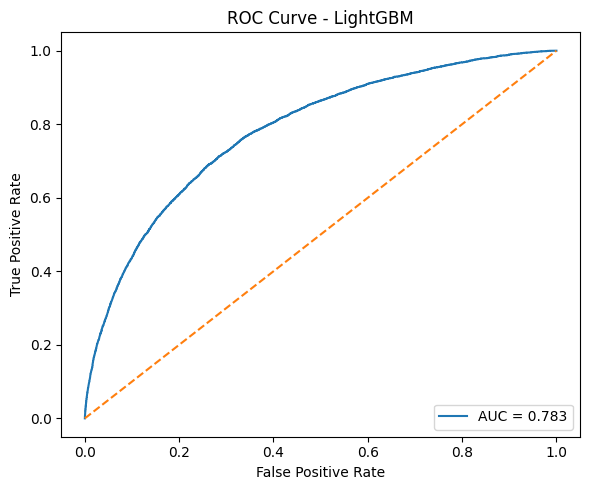

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model_lgb.predict_proba(X_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, y_proba)
auc_score = roc_auc_score(y_valid, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve - LightGBM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


AUC: 0.7812794909443754
              precision    recall  f1-score   support

           0       0.80      0.22      0.35     56538
           1       0.04      0.36      0.07      4965

    accuracy                           0.24     61503
   macro avg       0.42      0.29      0.21     61503
weighted avg       0.74      0.24      0.33     61503



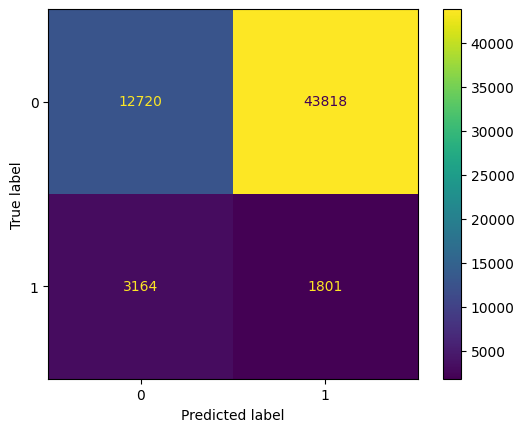

In [43]:
y_valid_proba = final_model.predict_proba(X_valid)[:, 1]
y_valid_pred = (y_valid_proba <0.5 ).astype(int)

print("AUC:", roc_auc_score(y_valid, y_valid_proba))
print(classification_report(y_valid, y_valid_pred))

cm = confusion_matrix(y_valid, y_valid_pred)
ConfusionMatrixDisplay(cm).plot()


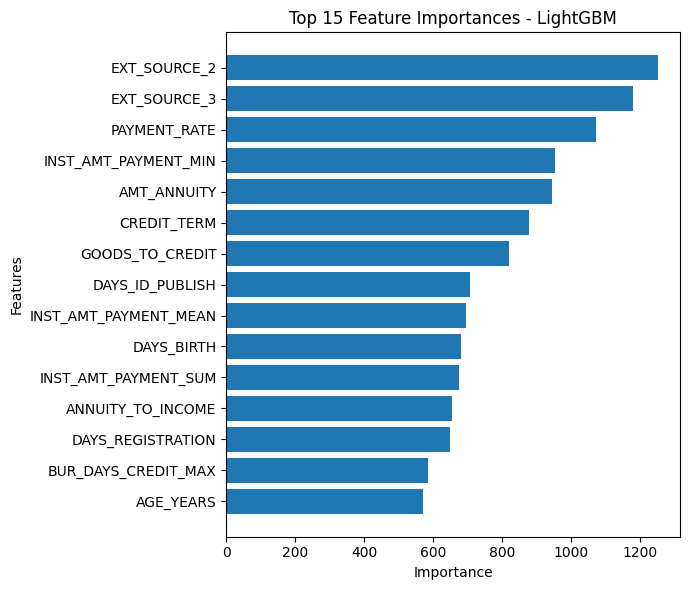

In [24]:
import numpy as np

feature_names = X_train.columns
importances = model_lgb.feature_importances_

indices = np.argsort(importances)[::-1]  # urut dari terbesar
top_n = 15
top_idx = indices[:top_n]

plt.figure(figsize=(7, 6))
plt.barh(range(top_n), importances[top_idx][::-1])
plt.yticks(range(top_n), feature_names[top_idx][::-1])
plt.title('Top 15 Feature Importances - LightGBM')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [17]:
# pakai sama ID_COL dan TARGET_COL
X_test = test.drop([ID_COL], axis=1)

In [29]:
# Samakan kolom train dan valid
X_train, X_valid = X_train.align(X_valid, join='left', axis=1, fill_value=0)

# Samakan kolom train dan test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [30]:
test_pred_proba = final_model.predict_proba(X_test)[:, 1]

In [31]:
test_pred = final_model.predict(X_test)

In [32]:
sub_pred = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET_COL: test_pred_proba
})

submission = df_sample[[ID_COL]].merge(sub_pred, on=ID_COL, how="left")
submission.to_csv("submission_lgbm_optuna.csv", index=False)

##XGBoost

In [36]:
pip install xgboost

In [37]:
import optuna
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

# === 1. Split data ===
X = train.drop([TARGET_COL, ID_COL], axis=1)
y = train[TARGET_COL]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)

# === 2. Objective untuk Optuna ===
def objective(trial):
    params = {
        "device": "cuda",              # pakai GPU
        "tree_method": "hist",         # v2: pakai hist + device=cuda
        "objective": "binary:logistic",
        "eval_metric": "auc",

        # hyperparameter yang DI-TUNING oleh Optuna:
        "eta": trial.suggest_float("eta", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 0.0, 5.0),
        "alpha": trial.suggest_float("alpha", 0.0, 5.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),

        # handling imbalance
        "scale_pos_weight": (len(y_train) - sum(y_train)) / sum(y_train),
    }

    evals = [(dtrain, "train"), (dvalid, "valid")]

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=3000,
        evals=evals,
        early_stopping_rounds=200,
        verbose_eval=False
    )

    preds = model.predict(dvalid)
    auc = roc_auc_score(y_valid, preds)
    return auc

# === 3. INI bagian Optuna-nya ===
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best AUC :", study.best_value)
print("Best Params :")
print(study.best_params)


[I 2025-12-06 16:14:41,592] A new study created in memory with name: no-name-2692450a-6913-407f-a277-7b8671e3a0dd
[I 2025-12-06 16:15:04,079] Trial 0 finished with value: 0.7789886932536386 and parameters: {'eta': 0.05204830418527296, 'max_depth': 5, 'subsample': 0.9120696440732047, 'colsample_bytree': 0.8658875271292972, 'lambda': 1.2591215857763065, 'alpha': 3.962586079645993, 'min_child_weight': 3.4439554737630016}. Best is trial 0 with value: 0.7789886932536386.
[I 2025-12-06 16:16:02,096] Trial 1 finished with value: 0.7756913164517109 and parameters: {'eta': 0.01814372747279938, 'max_depth': 8, 'subsample': 0.8560408052249444, 'colsample_bytree': 0.9991906248497218, 'lambda': 4.462878789498693, 'alpha': 3.3409896949992883, 'min_child_weight': 2.0712863452445225}. Best is trial 0 with value: 0.7789886932536386.
[I 2025-12-06 16:16:40,982] Trial 2 finished with value: 0.765107815267914 and parameters: {'eta': 0.038025303976776836, 'max_depth': 10, 'subsample': 0.8881285477237897, '

Best AUC : 0.7820691905491327
Best Params :
{'eta': 0.011238366943383076, 'max_depth': 4, 'subsample': 0.7404479563632678, 'colsample_bytree': 0.5003589104701491, 'lambda': 4.87899398353412, 'alpha': 2.3043362311252396, 'min_child_weight': 4.846366368620321}


In [38]:
best_params = study.best_params.copy()

best_params.update({
    "device": "cuda",
    "tree_method": "hist",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "scale_pos_weight": (len(y_train) - sum(y_train)) / sum(y_train),
})

final_xgb = xgb.train(
    best_params,
    dtrain,
    num_boost_round=3000,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=200,
    verbose_eval=False
)

AUC XGBoost (valid): 0.7821


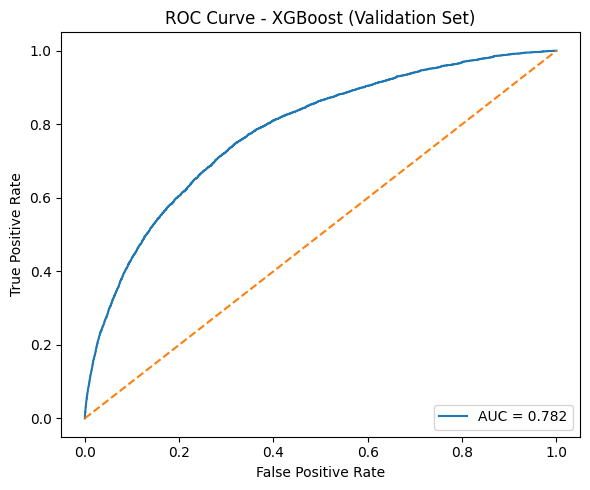

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# DMatrix valid
dvalid = xgb.DMatrix(X_valid, label=y_valid)

# Prediksi probabilitas
valid_proba = final_xgb.predict(dvalid)

# Hitung ROC
fpr, tpr, thresholds = roc_curve(y_valid, valid_proba)
auc_score = roc_auc_score(y_valid, valid_proba)
print(f"AUC XGBoost (valid): {auc_score:.4f}")

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Validation Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Confusion Matrix:
[[14299 42239]
 [ 3346  1619]]


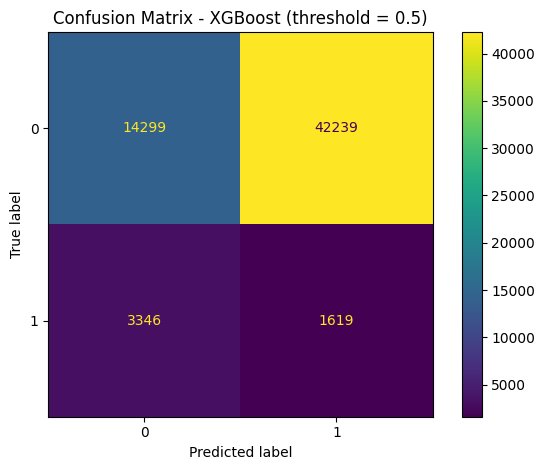

Classification Report:
              precision    recall  f1-score   support

           0     0.8104    0.2529    0.3855     56538
           1     0.0369    0.3261    0.0663      4965

    accuracy                         0.2588     61503
   macro avg     0.4236    0.2895    0.2259     61503
weighted avg     0.7479    0.2588    0.3597     61503



In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Pilih threshold
threshold = 0.5  # silakan sesuaikan (0.5, 0.3, 0.25, dll)

valid_pred = (valid_proba < threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_valid, valid_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title(f"Confusion Matrix - XGBoost (threshold = {threshold})")
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_valid, valid_pred, digits=4))


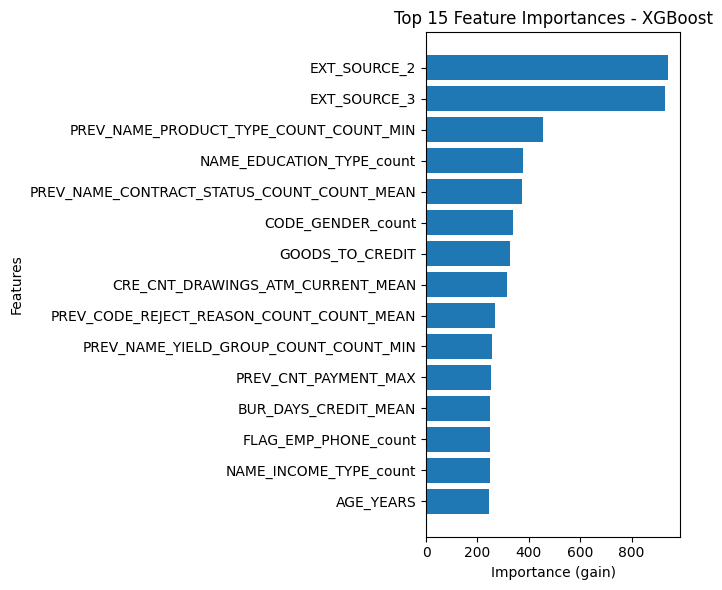

,feature,importance
13,EXT_SOURCE_2,941.308594
14,EXT_SOURCE_3,931.262695
195,PREV_NAME_PRODUCT_TYPE_COUNT_COUNT_MIN,454.119415
54,NAME_EDUCATION_TYPE_count,377.540863
166,PREV_NAME_CONTRACT_STATUS_COUNT_COUNT_MEAN,371.677307
49,CODE_GENDER_count,339.668243
40,GOODS_TO_CREDIT,326.882690
373,CRE_CNT_DRAWINGS_ATM_CURRENT_MEAN,314.432007
175,PREV_CODE_REJECT_REASON_COUNT_COUNT_MEAN,269.287842
210,PREV_NAME_YIELD_GROUP_COUNT_COUNT_MIN,255.022186


In [45]:
import pandas as pd
import numpy as np

# Ambil feature importance (berdasarkan gain)
fscore = final_xgb.get_score(importance_type='gain')  # atau 'weight', 'cover'

# Jadiin DataFrame
fi_df = pd.DataFrame({
    "feature": list(fscore.keys()),
    "importance": list(fscore.values())
})

# Sort descending
fi_df = fi_df.sort_values(by="importance", ascending=False)

# Ambil top 15
top_n = 15
top_fi = fi_df.head(top_n)

plt.figure(figsize=(7, 6))
plt.barh(top_fi["feature"][::-1], top_fi["importance"][::-1])
plt.xlabel("Importance (gain)")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

top_fi


In [58]:
dtest = xgb.DMatrix(X_test)

# probabilitas default (TARGET = 1)
test_pred_proba = final_xgb.predict(dtest)


In [59]:
test_pred = (test_pred_proba < 0.5).astype(int)   # threshold bebas

In [60]:
sub_pred = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET_COL: test_pred_proba
})

submission = df_sample[[ID_COL]].merge(sub_pred, on=ID_COL, how="left")
submission.to_csv("submission_cgboost_optuna.csv", index=False)

#EDA

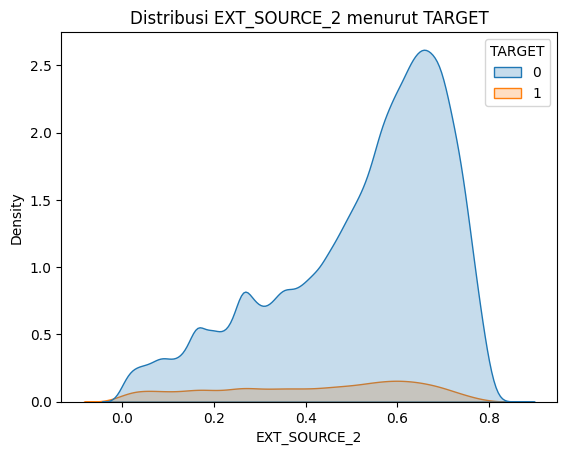

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=train, x="EXT_SOURCE_2", hue="TARGET", fill=True)
plt.title("Distribusi EXT_SOURCE_2 menurut TARGET")
plt.show()

<Axes: xlabel='AGE_YEARS', ylabel='Density'>

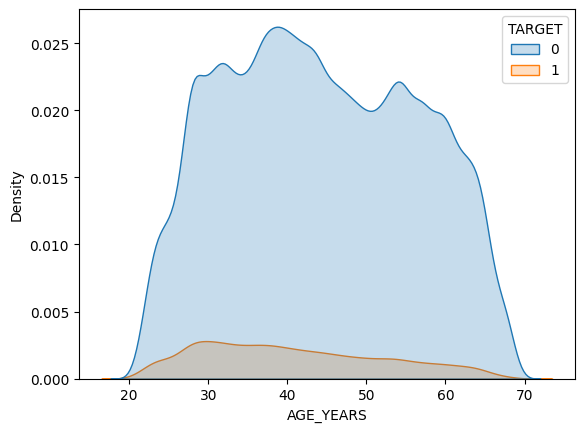

In [48]:
sns.kdeplot(data=train, x="AGE_YEARS", hue="TARGET", fill=True)

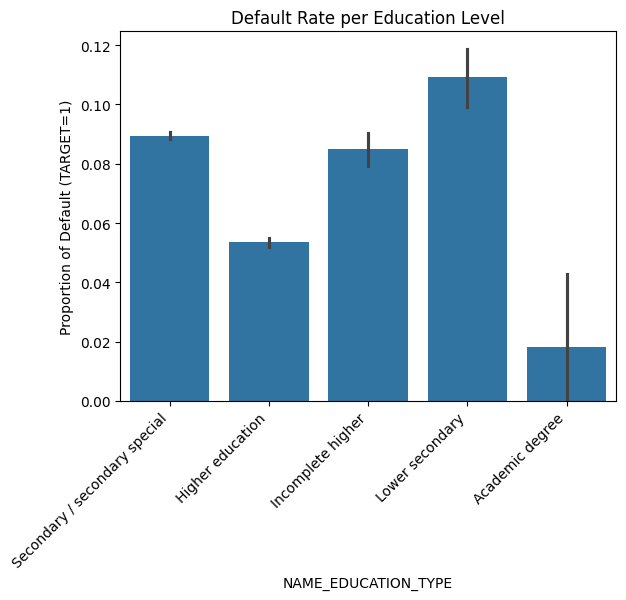

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=for_eda, x="NAME_EDUCATION_TYPE", y="TARGET")
plt.title("Default Rate per Education Level")
plt.ylabel("Proportion of Default (TARGET=1)")
plt.xticks(rotation=45, ha="right")

plt.show()

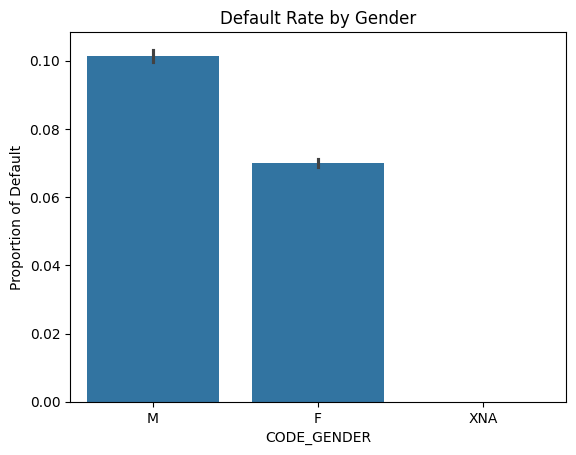

In [5]:
sns.barplot(data=for_eda, x="CODE_GENDER", y="TARGET")
plt.title("Default Rate by Gender")
plt.ylabel("Proportion of Default")
plt.show()


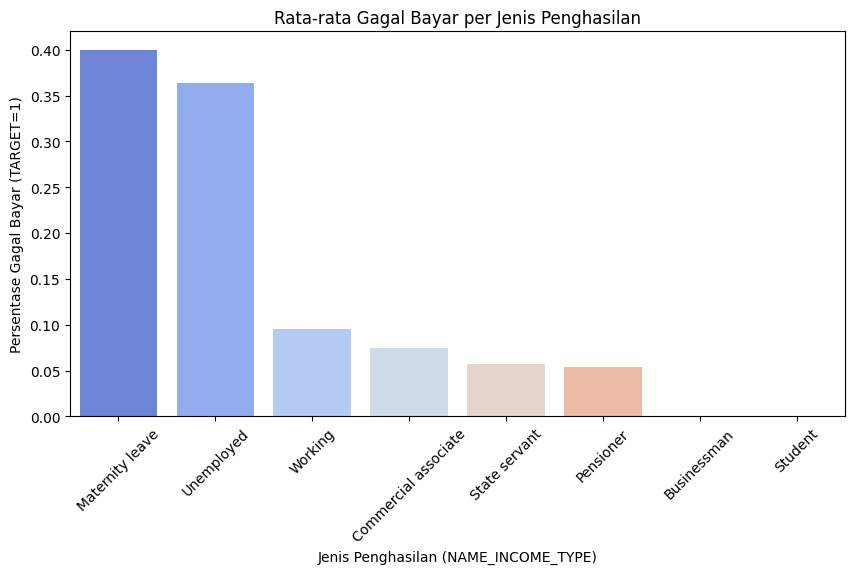

In [7]:
income_default = for_eda.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=income_default.index, y=income_default.values, hue=income_default.index, palette="coolwarm", legend=False)
plt.title("Rata-rata Gagal Bayar per Jenis Penghasilan")
plt.ylabel("Persentase Gagal Bayar (TARGET=1)")
plt.xlabel("Jenis Penghasilan (NAME_INCOME_TYPE)")
plt.xticks(rotation=45)
plt.show()

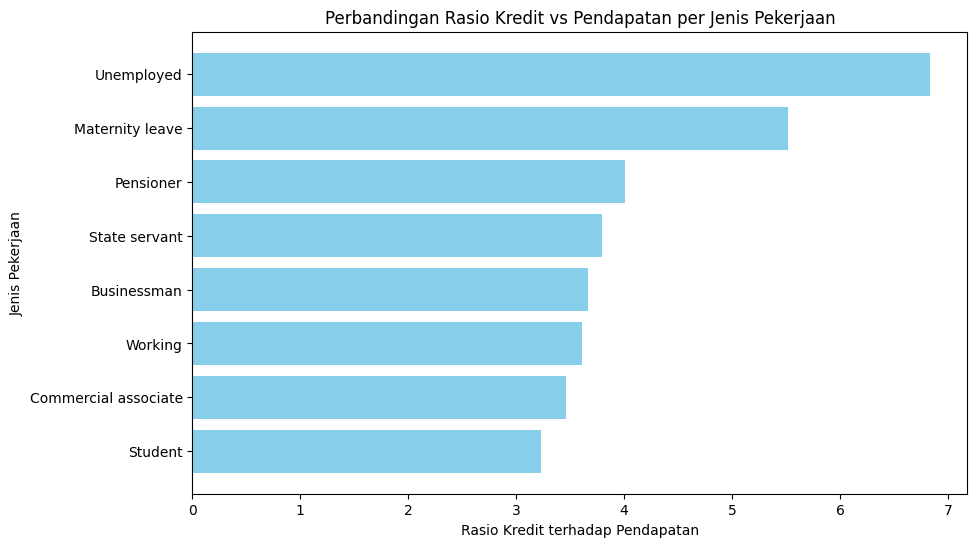

In [8]:
# Kelompokkan berdasarkan jenis pekerjaan
income_credit_summary = (
    for_eda.groupby('NAME_INCOME_TYPE')
    .agg({
        'AMT_INCOME_TOTAL': 'mean',
        'AMT_CREDIT': 'mean'
    })
    .reset_index()
)

# Tambahkan kolom rasio antara pinjaman dan pendapatan
income_credit_summary['Credit_to_Income_Ratio'] = (
    income_credit_summary['AMT_CREDIT'] / income_credit_summary['AMT_INCOME_TOTAL']
)

income_credit_summary.sort_values(by='Credit_to_Income_Ratio', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
plt.barh(income_credit_summary['NAME_INCOME_TYPE'], income_credit_summary['Credit_to_Income_Ratio'], color='skyblue')
plt.xlabel('Rasio Kredit terhadap Pendapatan')
plt.ylabel('Jenis Pekerjaan')
plt.title('Perbandingan Rasio Kredit vs Pendapatan per Jenis Pekerjaan')
plt.gca().invert_yaxis()
plt.show()
